In [1]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, Dataset, DataLoader
import os
import pandas as pd

 
from torchinfo import summary

%matplotlib inline

# DATA

In [2]:
bulk = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/merged/merged_expanded.csv', index_col=0)

In [72]:
import sys
sys.path.append('/mnt/jack-5/amismailov/miRNA_study')
import importlib, bootstrap
importlib.reload(bootstrap)

path_mrna = '/mnt/jack-5/amismailov/miRNA_study/single_cell/mRNA_counts.csv'
path_mir = '/mnt/jack-5/amismailov/miRNA_study/single_cell/miRNA_counts.csv'
path_barcodes = '/mnt/jack-5/amismailov/miRNA_study/single_cell/barcodes_combined_filtered.csv' 
path_length = '/mnt/jack-5/amismailov/miRNA_study/df_gene_mapping.parquet'

boot = bootstrap.Bootstrap(path_mrna, path_mir, path_barcodes, path_length)

In [85]:
x, y = boot.generate('293T-MS', K=2, N=5)
shared_genes = sorted(list(set(x.index.tolist()) & set(bulk.index.tolist())))

In [95]:
# filter out
bulk = bulk[bulk.index.isin(shared_genes)]

In [81]:
rna_data_ss = [] 
for tissue in boot.get_tissues():
    for k, n in zip([2, 5], [2000, 1000]):
        x, y = boot.generate(tissue, K=k, N=n)
        rna_data_ss.append(x) 
rna_data_ss = pd.concat(rna_data_ss, axis=1)

In [88]:
rna_data_ss = rna_data_ss[rna_data_ss.index.isin(shared_genes)]
rna_data_ss.head()

,bootstrap_K2_293T-MS_0,bootstrap_K2_293T-MS_1,bootstrap_K2_293T-MS_10,bootstrap_K2_293T-MS_100,bootstrap_K2_293T-MS_1000,bootstrap_K2_293T-MS_1001,bootstrap_K2_293T-MS_1002,bootstrap_K2_293T-MS_1003,bootstrap_K2_293T-MS_1004,bootstrap_K2_293T-MS_1005,...,bootstrap_K5_K562-MS_990,bootstrap_K5_K562-MS_991,bootstrap_K5_K562-MS_992,bootstrap_K5_K562-MS_993,bootstrap_K5_K562-MS_994,bootstrap_K5_K562-MS_995,bootstrap_K5_K562-MS_996,bootstrap_K5_K562-MS_997,bootstrap_K5_K562-MS_998,bootstrap_K5_K562-MS_999
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,5.671387,5.143719,4.506005,5.179586,5.920257,3.540132,5.633782,5.981479,6.455770,6.982823,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000005,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.483132,0.000000,0.000000
ENSG00000000419,3.773497,1.596769,3.443103,2.244517,4.840135,4.003638,1.951392,4.046349,1.585599,3.633525,...,4.074606,3.875872,2.759158,3.869628,3.738348,3.723892,4.477093,4.041977,4.222474,3.037860
ENSG00000000457,0.000000,0.000000,0.000000,0.000000,2.338249,1.551579,0.000000,1.803883,0.000000,2.556873,...,0.994795,0.271047,0.454672,1.968806,2.439454,0.393594,0.796244,0.191459,1.047993,0.000000
ENSG00000000460,0.520082,0.326778,0.869227,0.769049,1.163230,0.000000,0.443640,0.314543,1.003689,0.000000,...,0.748035,0.489721,0.063888,0.464616,1.032414,1.052001,0.678218,0.537023,0.762084,0.143384


In [89]:
print(f'BULK data shape: {bulk.shape}')
print(f'SS data shape: {rna_data_ss.shape}')

BULK data shape: (17409, 35664)
SS data shape: (17409, 12000)


In [96]:
bulk = np.log2(bulk+1)

In [97]:
df = pd.concat([bulk, rna_data_ss], axis=1)
df.shape

(17409, 47664)

In [101]:
df

,BLGSP-71-06-00001-01A,BLGSP-71-06-00001-01B,BLGSP-71-06-00002-01C,BLGSP-71-06-00002-01D,BLGSP-71-06-00004-01A,BLGSP-71-06-00004-01B,BLGSP-71-06-00005-01A,BLGSP-71-06-00005-01B,BLGSP-71-06-00007-01A,BLGSP-71-06-00007-01B,...,bootstrap_K5_K562-MS_990,bootstrap_K5_K562-MS_991,bootstrap_K5_K562-MS_992,bootstrap_K5_K562-MS_993,bootstrap_K5_K562-MS_994,bootstrap_K5_K562-MS_995,bootstrap_K5_K562-MS_996,bootstrap_K5_K562-MS_997,bootstrap_K5_K562-MS_998,bootstrap_K5_K562-MS_999
ENSG00000000003,0.978269,0.871496,0.737150,1.173621,0.724096,0.305378,0.712700,0.503265,1.165845,1.434961,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000005,0.011125,0.039134,0.000000,0.027615,0.000000,0.076117,0.000000,0.000000,0.010552,0.066764,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.483132,0.000000,0.000000
ENSG00000000419,3.298437,2.633262,2.534117,2.489351,3.454194,2.686042,3.563853,2.419998,3.417236,2.550618,...,4.074606,3.875872,2.759158,3.869628,3.738348,3.723892,4.477093,4.041977,4.222474,3.037860
ENSG00000000457,2.119546,2.809700,2.353478,2.939598,1.910522,2.712348,1.893098,2.650707,1.854248,2.597269,...,0.994795,0.271047,0.454672,1.968806,2.439454,0.393594,0.796244,0.191459,1.047993,0.000000
ENSG00000000460,1.083592,1.451006,1.214571,1.507403,1.300963,1.549425,1.227129,1.444398,1.294821,1.529838,...,0.748035,0.489721,0.063888,0.464616,1.032414,1.052001,0.678218,0.537023,0.762084,0.143384
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000286264,1.420150,0.857482,1.047710,1.161123,1.425292,0.793410,1.131555,2.022860,1.201945,0.891131,...,6.108388,5.957081,5.801709,6.315249,6.536385,6.839346,6.593068,6.445429,6.134271,6.255681
ENSG00000286522,3.263951,12.457629,13.882127,11.994071,3.538919,11.777196,2.982477,11.401402,4.544490,12.884889,...,6.537166,7.075559,6.120299,6.987077,8.097760,6.200934,6.976848,4.769011,7.052365,5.748036
ENSG00000286920,0.167172,0.327182,0.229091,0.140432,0.000000,0.099836,0.194128,0.449926,0.054966,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000287080,2.695305,10.380675,11.189609,8.710529,1.982013,9.565329,2.759071,9.256798,4.109267,10.835724,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [72]:
#df.to_parquet('/mnt/jack-5/amismailov/miRNA_study/AE/AE_data.parquet')
df = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/AE/AE_data.parquet')

In [3]:
X = torch.tensor(df.values.T, dtype=torch.float32)

In [4]:
from torch.utils.data import random_split

dataset = TensorDataset(X)  
n_total = len(dataset)  # 47664
val_frac = 0.2          # 20 % для валидации
n_val = int(n_total * val_frac)
n_train = n_total - n_val

train_dataset, val_dataset = random_split(
    dataset,
    lengths=[n_train, n_val],
    generator=torch.Generator().manual_seed(42)  # для воспроизводимости
)

In [91]:
batch_size = 64
use_cuda = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,       # перемешиваем каждую эпоху
    num_workers=4,
    pin_memory=False#use_cuda
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,      # фиксированный порядок на валидации
    num_workers=2,
    pin_memory=False#use_cuda
)


# MODEL

In [161]:
import sys
sys.path.append('/mnt/jack-5/amismailov/miRNA_study/AE')
import importlib, Train_VAE
importlib.reload(Train_VAE)
from Train_VAE import VAE

In [162]:
input_size = df.shape[0]

autoencoder = VAE() 


summary(
    autoencoder,
    input_size=(16,17409),
    device="cpu",
    verbose=0,
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"]
)

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
VAE (VAE)                                [16, 17409]          [16, 256]            --                   True
├─Sequential (encode_block)              [16, 17409]          [16, 512]            --                   True
│    └─Linear (0)                        [16, 17409]          [16, 8192]           142,622,720          True
│    └─BatchNorm1d (1)                   [16, 8192]           [16, 8192]           16,384               True
│    └─ReLU (2)                          [16, 8192]           [16, 8192]           --                   --
│    └─Dropout (3)                       [16, 8192]           [16, 8192]           --                   --
│    └─Linear (4)                        [16, 8192]           [16, 4096]           33,558,528           True
│    └─BatchNorm1d (5)                   [16, 4096]           [16, 4096]           8,192                True
│    └─ReLU (6)   

In [119]:
def kl_divergence(mu, logvar):
    """
    KL(N(mu, sigma) || N(0,1)) по всем элементам батча.
    """
    # суммируем по латентным признакам и по всем эземплярам
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

def reconstruction_loss(x, recon_x, reduction='mean'):
    """
    MSE Loss между входом и реконструкцией.
    reduction: 'sum' или 'mean'
    """
    return nn.functional.mse_loss(recon_x, x, reduction=reduction)

def criterion(x, mu, logvar, recon_x, beta=1.0):
    """
    VAE loss = Reconstruction + beta * KL.
      beta=1.0 для обычного VAE, beta>1 для beta-VAE.
    """
    # MSE суммарно по батчу
    recon = reconstruction_loss(x, recon_x, reduction='sum')
    kl = kl_divergence(mu, logvar)
    return recon + beta * kl, recon, kl



'''
def criterion(x, mu, logvar, recon_x, beta=1.0):
    recon = reconstruction_loss(x, recon_x, reduction='sum')
    kl = kl_divergence(mu, logvar)
    batch_size = x.size(0)
    loss = (recon + beta * kl) / batch_size
    return loss, recon / batch_size, kl / batch_size
'''
None

In [137]:
from IPython.display import clear_output
from tqdm.auto import tqdm
from copy import deepcopy

def train(model, train_loader, val_loader, n_epochs, optimizer, loss_fn, device):
    train_losses, val_losses = [], []
    train_recons, val_recons = [], []
    train_kls, val_kls = [], []
    
    best_loss = float('inf') 
    best_weights = None
    
    for epoch in tqdm(range(1, n_epochs+1), desc="Epochs", leave=False):
        print(f'* Epoch {epoch}/{n_epochs}')
        
        # ------- Training -------
        model.train()
        total_train_loss = 0.0
        total_train_recon = 0.0
        total_train_kl = 0.0
        for (batch_X,) in train_loader:
            batch_X = batch_X.to(device)
            optimizer.zero_grad()
            mu, logvar, recon = model(batch_X)
            loss, recon_term, kl_term = loss_fn(batch_X, mu, logvar, recon)
            loss.backward()
            optimizer.step()
            
            total_train_loss  += loss.item()
            total_train_recon += recon_term.item()
            total_train_kl    += kl_term.item()

        # Усредняем по числу sample’ов
        n_train_samples = len(train_loader.dataset)
        train_losses.append(total_train_loss  / n_train_samples)
        train_recons.append(total_train_recon / n_train_samples)
        train_kls.append(total_train_kl       / n_train_samples)

        # ------- Validation -------
        model.eval()
        total_val_loss = 0.0
        total_val_recon = 0.0
        total_val_kl = 0.0
        with torch.no_grad():
            for (batch_X,) in val_loader:
                batch_X = batch_X.to(device)
                mu, logvar, recon = model(batch_X)
                loss, recon_term, kl_term = loss_fn(batch_X, mu, logvar, recon)
                total_val_loss  += loss.item()
                total_val_recon += recon_term.item()
                total_val_kl    += kl_term.item()

        n_val_samples = len(val_loader.dataset)
        current_loss = total_val_loss  / n_val_samples
        val_losses.append(current_loss)
        val_recons.append(total_val_recon / n_val_samples)
        val_kls.append(total_val_kl       / n_val_samples)

        if current_loss < best_loss:
            best_loss = current_loss
            best_weights = deepcopy(model.state_dict())

        print(f"Train   Loss: {train_losses[-1]:.4f} (Recon {train_recons[-1]:.4f}, KL {train_kls[-1]:.4f})")
        print(f"Validate Loss: {val_losses[-1]:.4f} (Recon {val_recons[-1]:.4f}, KL {val_kls[-1]:.4f})\n")
    
    if best_weights is not None:
        model.load_state_dict(best_weights)

    return {
        'train_loss': train_losses,
        'train_recon': train_recons,
        'train_kl': train_kls,
        'val_loss': val_losses,
        'val_recon': val_recons,
        'val_kl': val_kls,
        'best_val_loss': best_loss,
    }

In [138]:
#device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device = 'cpu'

In [139]:
torch.cuda.empty_cache()

In [163]:
autoencoder = VAE().to(device)

# 2. Инициализация весов
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

autoencoder.apply(init_weights)

VAE(
  (encode_block): Sequential(
    (0): Linear(in_features=17409, out_features=8192, bias=True)
    (1): BatchNorm1d(8192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=8192, out_features=4096, bias=True)
    (5): BatchNorm1d(4096, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=4096, out_features=2048, bias=True)
    (9): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=2048, out_features=1024, bias=True)
    (13): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Linear(in_features=1024, out_features=512, bias=True)
  )
  (decode_block): Sequential(
    (0): Linear(in_features=256, out_features=1024, bias=Tru

In [164]:
n_epochs = 10
optimizer = optim.AdamW(autoencoder.parameters(), lr=1e-3, weight_decay=1e-5)

results = train(model=autoencoder, 
                train_loader=train_loader, 
                val_loader=val_loader, 
                n_epochs=n_epochs, 
                optimizer=optimizer,
                loss_fn=criterion,
                device=device)

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

* Epoch 1/10
Train   Loss: 14760.1350 (Recon 14522.2480, KL 237.8869)
Validate Loss: 8551.8561 (Recon 8325.9529, KL 225.9032)

* Epoch 2/10
Train   Loss: 7910.2778 (Recon 7697.7838, KL 212.4940)
Validate Loss: 7637.3261 (Recon 7424.6517, KL 212.6745)

* Epoch 3/10
Train   Loss: 6864.9399 (Recon 6677.2814, KL 187.6585)
Validate Loss: 6391.2181 (Recon 6217.7567, KL 173.4614)

* Epoch 4/10
Train   Loss: 6405.3978 (Recon 6222.2300, KL 183.1677)
Validate Loss: 6326.2871 (Recon 6117.9847, KL 208.3023)

* Epoch 5/10
Train   Loss: 6243.8980 (Recon 6046.6676, KL 197.2304)
Validate Loss: 5920.5968 (Recon 5749.7646, KL 170.8322)

* Epoch 6/10
Train   Loss: 5907.0298 (Recon 5737.1981, KL 169.8317)
Validate Loss: 9662.1691 (Recon 9294.1996, KL 367.9694)

* Epoch 7/10
Train   Loss: 5995.9868 (Recon 5803.2410, KL 192.7457)
Validate Loss: 5681.7146 (Recon 5545.9200, KL 135.7947)

* Epoch 8/10
Train   Loss: 5655.8448 (Recon 5511.6596, KL 144.1852)
Validate Loss: 5440.1305 (Recon 5307.1902, KL 132.9404)

In [170]:
n_epochs = 25
results = train(model=autoencoder, 
                train_loader=train_loader, 
                val_loader=val_loader, 
                n_epochs=n_epochs, 
                optimizer=optimizer,
                loss_fn=criterion,
                device=device)

Epochs:   0%|          | 0/25 [00:00<?, ?it/s]

* Epoch 1/25
Train   Loss: 5458.1400 (Recon 5318.7169, KL 139.4231)
Validate Loss: 5292.5019 (Recon 5150.4817, KL 142.0202)

* Epoch 2/25
Train   Loss: 5341.8532 (Recon 5211.5540, KL 130.2991)
Validate Loss: 5386.0248 (Recon 5270.9508, KL 115.0740)

* Epoch 3/25
Train   Loss: 5294.2525 (Recon 5170.7776, KL 123.4749)
Validate Loss: 5139.5544 (Recon 5020.2436, KL 119.3108)

* Epoch 4/25
Train   Loss: 5291.9814 (Recon 5164.0829, KL 127.8986)
Validate Loss: 5329.2393 (Recon 5188.4061, KL 140.8332)

* Epoch 5/25
Train   Loss: 5177.3850 (Recon 5062.3526, KL 115.0324)
Validate Loss: 5330.9023 (Recon 5211.3535, KL 119.5487)

* Epoch 6/25


KeyboardInterrupt: 

In [172]:
def kl_divergence(mu, logvar):
    """
    KL(N(mu, sigma) || N(0,1)) по всем элементам батча.
    """
    # суммируем по латентным признакам и по всем эземплярам
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

def reconstruction_loss(x, recon_x, reduction='mean'):
    """
    MSE Loss между входом и реконструкцией.
    reduction: 'sum' или 'mean'
    """
    return nn.functional.mse_loss(recon_x, x, reduction=reduction)

def criterion(x, mu, logvar, recon_x, beta=1.5):
    """
    VAE loss = Reconstruction + beta * KL.
      beta=1.0 для обычного VAE, beta>1 для beta-VAE.
    """
    # MSE суммарно по батчу
    recon = reconstruction_loss(x, recon_x, reduction='sum')
    kl = kl_divergence(mu, logvar)
    return recon + beta * kl, recon, kl

In [173]:
n_epochs = 10
optimizer = optim.AdamW(autoencoder.parameters(), lr=1e-4, weight_decay=1e-4)

results = train(model=autoencoder, 
                train_loader=train_loader, 
                val_loader=val_loader, 
                n_epochs=n_epochs, 
                optimizer=optimizer,
                loss_fn=criterion,
                device=device)

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

* Epoch 1/10
Train   Loss: 4930.0437 (Recon 4786.5844, KL 95.6395)
Validate Loss: 4794.6247 (Recon 4668.4690, KL 84.1038)

* Epoch 2/10
Train   Loss: 4845.2591 (Recon 4720.9976, KL 82.8410)
Validate Loss: 4760.4764 (Recon 4641.8508, KL 79.0838)

* Epoch 3/10
Train   Loss: 4809.9818 (Recon 4691.3592, KL 79.0817)
Validate Loss: 4741.9183 (Recon 4629.5275, KL 74.9272)

* Epoch 4/10
Train   Loss: 4783.4648 (Recon 4667.4734, KL 77.3276)
Validate Loss: 4719.1467 (Recon 4607.2002, KL 74.6310)

* Epoch 5/10
Train   Loss: 4760.6948 (Recon 4647.9156, KL 75.1861)
Validate Loss: 4705.1467 (Recon 4596.9700, KL 72.1178)

* Epoch 6/10
Train   Loss: 4747.4409 (Recon 4635.9257, KL 74.3435)
Validate Loss: 4698.2407 (Recon 4590.7971, KL 71.6291)

* Epoch 7/10
Train   Loss: 4725.8088 (Recon 4615.5964, KL 73.4749)
Validate Loss: 4680.3065 (Recon 4574.0286, KL 70.8520)

* Epoch 8/10
Train   Loss: 4707.6314 (Recon 4598.6698, KL 72.6411)
Validate Loss: 4675.6673 (Recon 4570.9477, KL 69.8130)

* Epoch 9/10
Tra

In [174]:
autoencoder.eval()
with torch.no_grad():
    sample_batch = next(iter(val_loader))[0][:63].to(device)  # 5 образцов
    mu, logvar, recon = autoencoder(sample_batch)
    
    # Корреляция между оригиналом и реконструкцией
    correlations = []
    for i in range(63):
        orig = sample_batch[i].cpu().numpy()
        rec = recon[i].cpu().numpy()
        corr = np.corrcoef(orig, rec)[0,1]
        correlations.append(corr)
    
    print(f"Средняя корреляция реконструкции: {np.mean(correlations):.3f}")

Средняя корреляция реконструкции: 0.974


In [175]:
vector = next(iter(val_loader))[0][:1]
vector

tensor([[4.2113, 0.3407, 3.5552,  ..., 0.0000, 3.2006, 0.0000]])

In [176]:
autoencoder.eval()
with torch.no_grad():
    mu, logvar, recon = autoencoder(vector)
recon

tensor([[5.0755e+00, 2.4376e-01, 3.8241e+00,  ..., 1.1750e-02, 1.0394e+00,
         4.0751e-03]])

In [68]:
latent.shape

torch.Size([1, 1024])

In [177]:
torch.save(autoencoder.state_dict(), "/mnt/jack-5/amismailov/miRNA_study/AE/vae_weights_light.pth")

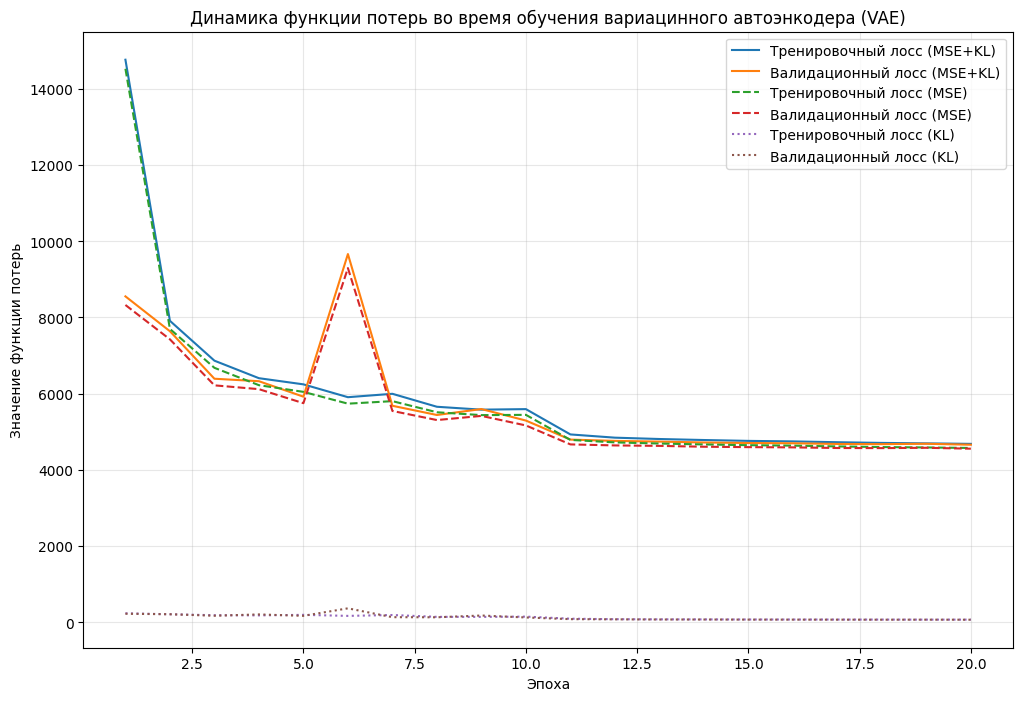

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Ручной ввод данных: 2 последовательных цикла обучения по 10 эпох каждый
data = {
    "epoch": list(range(1, 11)) + list(range(1, 11)),
    "Train Total": [
        14760.1350, 7910.2778, 6864.9399, 6405.3978, 6243.8980, 5907.0298, 5995.9868, 5655.8448, 5579.9973, 5593.9692,
        4930.0437, 4845.2591, 4809.9818, 4783.4648, 4760.6948, 4747.4409, 4725.8088, 4707.6314, 4695.7533, 4682.3520
    ],
    "Train Recon": [
        14522.2480, 7697.7838, 6677.2814, 6222.2300, 6046.6676, 5737.1981, 5803.2410, 5511.6596, 5436.6746, 5443.7531,
        4786.5844, 4720.9976, 4691.3592, 4667.4734, 4647.9156, 4635.9257, 4615.5964, 4598.6698, 4588.4410, 4574.8281
    ],
    "Train KL": [
        237.8869, 212.4940, 187.6585, 183.1677, 197.2304, 169.8317, 192.7457, 144.1852, 143.3227, 150.2161,
        95.6395, 82.8410, 79.0817, 77.3276, 75.1861, 74.3435, 73.4749, 72.6411, 71.5415, 71.6826
    ],
    "Val Total": [
        8551.8561, 7637.3261, 6391.2181, 6326.2871, 5920.5968, 9662.1691, 5681.7146, 5440.1305, 5595.9676, 5293.8563,
        4794.6247, 4760.4764, 4741.9183, 4719.1467, 4705.1467, 4698.2407, 4680.3065, 4675.6673, 4685.0581, 4659.7033
    ],
    "Val Recon": [
        8325.9529, 7424.6517, 6217.7567, 6117.9847, 5749.7646, 9294.1996, 5545.9200, 5307.1902, 5416.3468, 5165.7620,
        4668.4690, 4641.8508, 4629.5275, 4607.2002, 4596.9700, 4590.7971, 4574.0286, 4570.9477, 4579.4095, 4555.8956
    ],
    "Val KL": [
        225.9032, 212.6745, 173.4614, 208.3023, 170.8322, 367.9694, 135.7947, 132.9404, 179.6208, 128.0942,
        84.1038, 79.0838, 74.9272, 74.6310, 72.1178, 71.6291, 70.8520, 69.8130, 70.4324, 69.2051
    ]
}

df = pd.DataFrame(data)

# Порядковые номера для общего графика (чтобы "вторая десятка эпох" шла следом)
df["epoch_total"] = list(range(1, 21))

plt.figure(figsize=(12, 8))
plt.plot(df["epoch_total"], df["Train Total"], label='Тренировочный лосс (MSE+KL)')
plt.plot(df["epoch_total"], df["Val Total"], label='Валидационный лосс (MSE+KL)')
plt.plot(df["epoch_total"], df["Train Recon"], '--', label='Тренировочный лосс (MSE)')
plt.plot(df["epoch_total"], df["Val Recon"], '--', label='Валидационный лосс (MSE)')
plt.plot(df["epoch_total"], df["Train KL"], ':', label='Тренировочный лосс (KL)')
plt.plot(df["epoch_total"], df["Val KL"], ':', label='Валидационный лосс (KL)')

plt.xlabel("Эпоха")
plt.ylabel("Значение функции потерь")
plt.legend(loc='upper right')
plt.title("Динамика функции потерь во время обучения вариацинного автоэнкодера (VAE)")
plt.grid(True, alpha=0.3)
plt.show()
